In [ ]:
%load_ext autoreload
%autoreload 2

# 067: KmerSeek HP SCOPe40 — All Metrics AUC Sweep (all FPs, no gray-zone exclusion)

This notebook uses `exclude_gray_zone=False` (legacy / inclusive FP convention).
All analysis logic lives in `066_shared.py`.

In [1]:
import importlib.util
import sys
from pathlib import Path

_here = next(
    p for p in [Path.cwd(), Path.cwd() / 'notebooks']
    if (p / '066_shared.py').exists()
)
_spec = importlib.util.spec_from_file_location('_shared_066', _here / '066_shared.py')
_mod  = importlib.util.module_from_spec(_spec)
sys.modules['_shared_066'] = _mod
_spec.loader.exec_module(_mod)
from _shared_066 import *  # noqa: F401,F403

EXCLUDE_GRAY_ZONE = False
FIG_PREFIX = '../figures/066_all_fps'
Path('../figures').mkdir(exist_ok=True)
print(f'exclude_gray_zone={EXCLUDE_GRAY_ZONE}')

exclude_gray_zone=False


## 1. Load baselines

In [2]:
foldseek, tea_all, ref_queries = load_scope_baselines()

FoldSeek: 5,713 queries
TEA:      5,737 queries
Benchmarkable query set: 5,713 queries
FoldSeek: FAM=0.8169  SFAM=0.5743  FOLD=0.1017
TEA: FAM=0.8020  SFAM=0.5804  FOLD=0.0868


## 2. AUC sweep (all metrics × k=15–45)

In [3]:
auc_df = run_auc_sweep(EXCLUDE_GRAY_ZONE, ref_queries)

Loaded cached sweep (all_fps): 403 rows


## 3. AUC heatmap

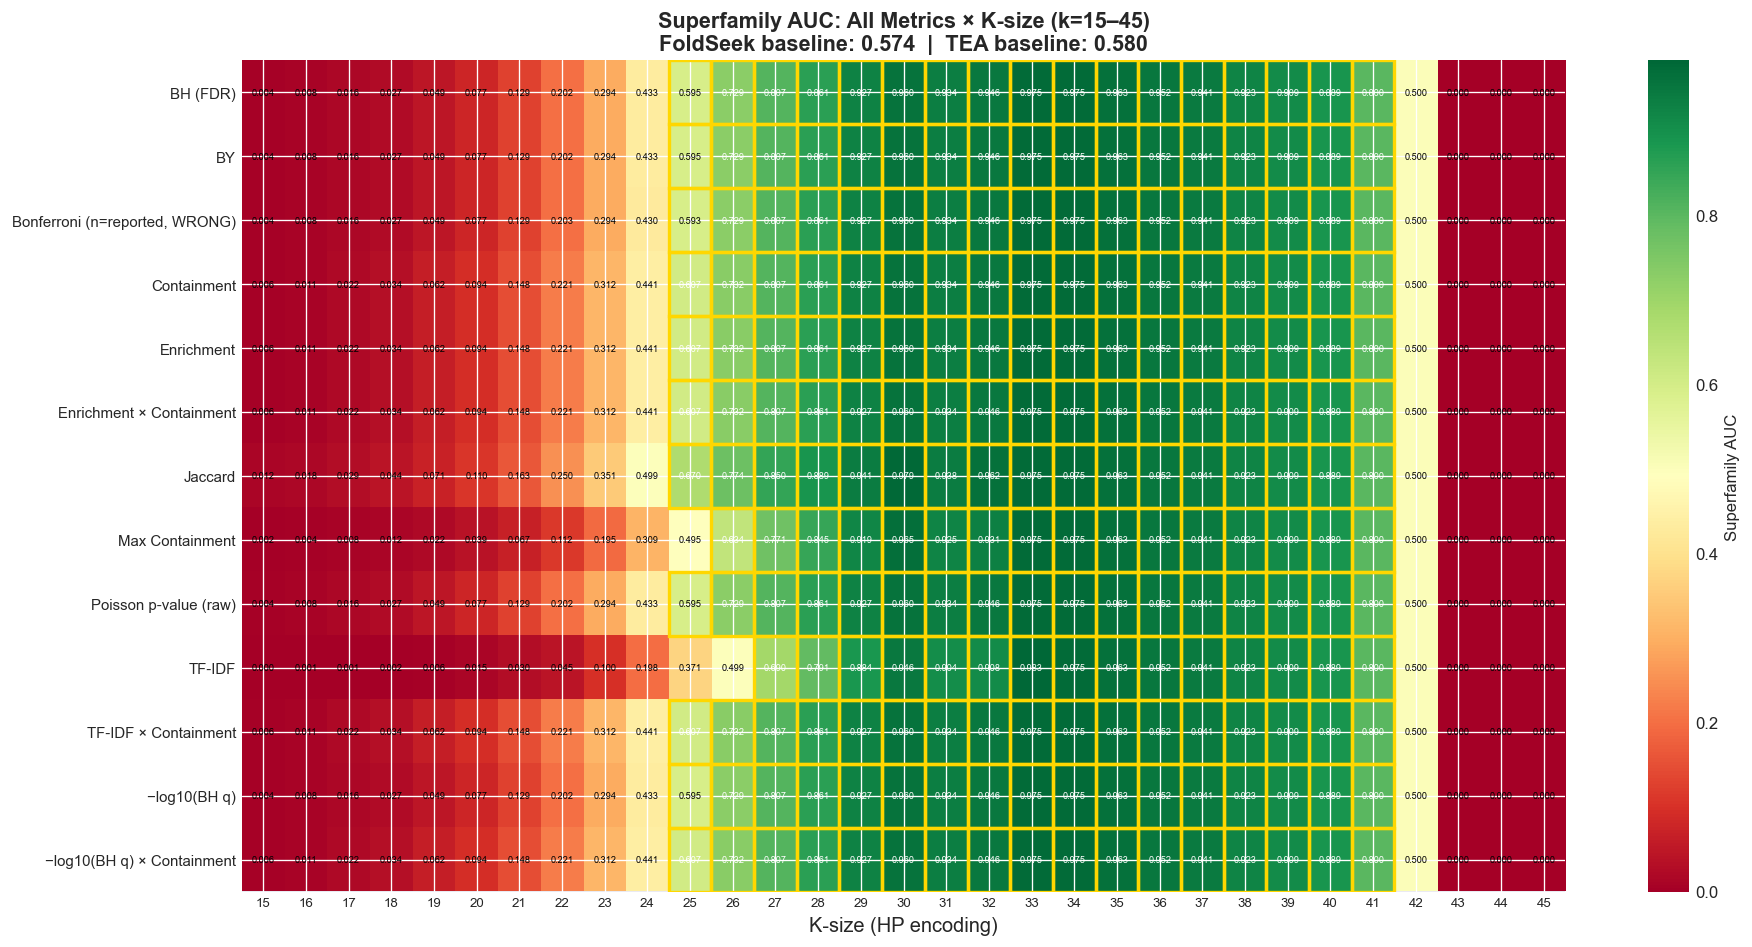

Gold boxes = beats FoldSeek (0.574)


In [4]:
plot_auc_heatmap(auc_df, foldseek, tea_all, FIG_PREFIX)

## 4. Best metric

In [5]:
best = get_best_metric(auc_df, foldseek, tea_all)
best

=== BEST COMBINATION ===
  K-size:          27
  Metric:          Jaccard (jaccard)
  n_queries:       163
  Family AUC:      0.8027
  Superfamily AUC: 0.8497  (FoldSeek: 0.5743, TEA: 0.5804)
  Fold AUC:        0.8579


{'ksize': 27,
 'score_col': 'jaccard',
 'label': 'Jaccard',
 'auc_class_all': 0.87989,
 'auc_sfam_all': 0.83561,
 'auc_fam_all': 0.80114,
 'auc_fold_all': 0.83864,
 'n_queries_all': 440,
 'auc_class': 0.89969,
 'auc_sfam': 0.84969,
 'auc_fam': 0.80266,
 'auc_fold': 0.85787,
 'n_queries': 163}

## 5. Best-metric sensitivity curve

Best k=27  metric=Bonferroni<0.05 | Jaccard
  AUC (all covered): 0.9234  N covered: 248


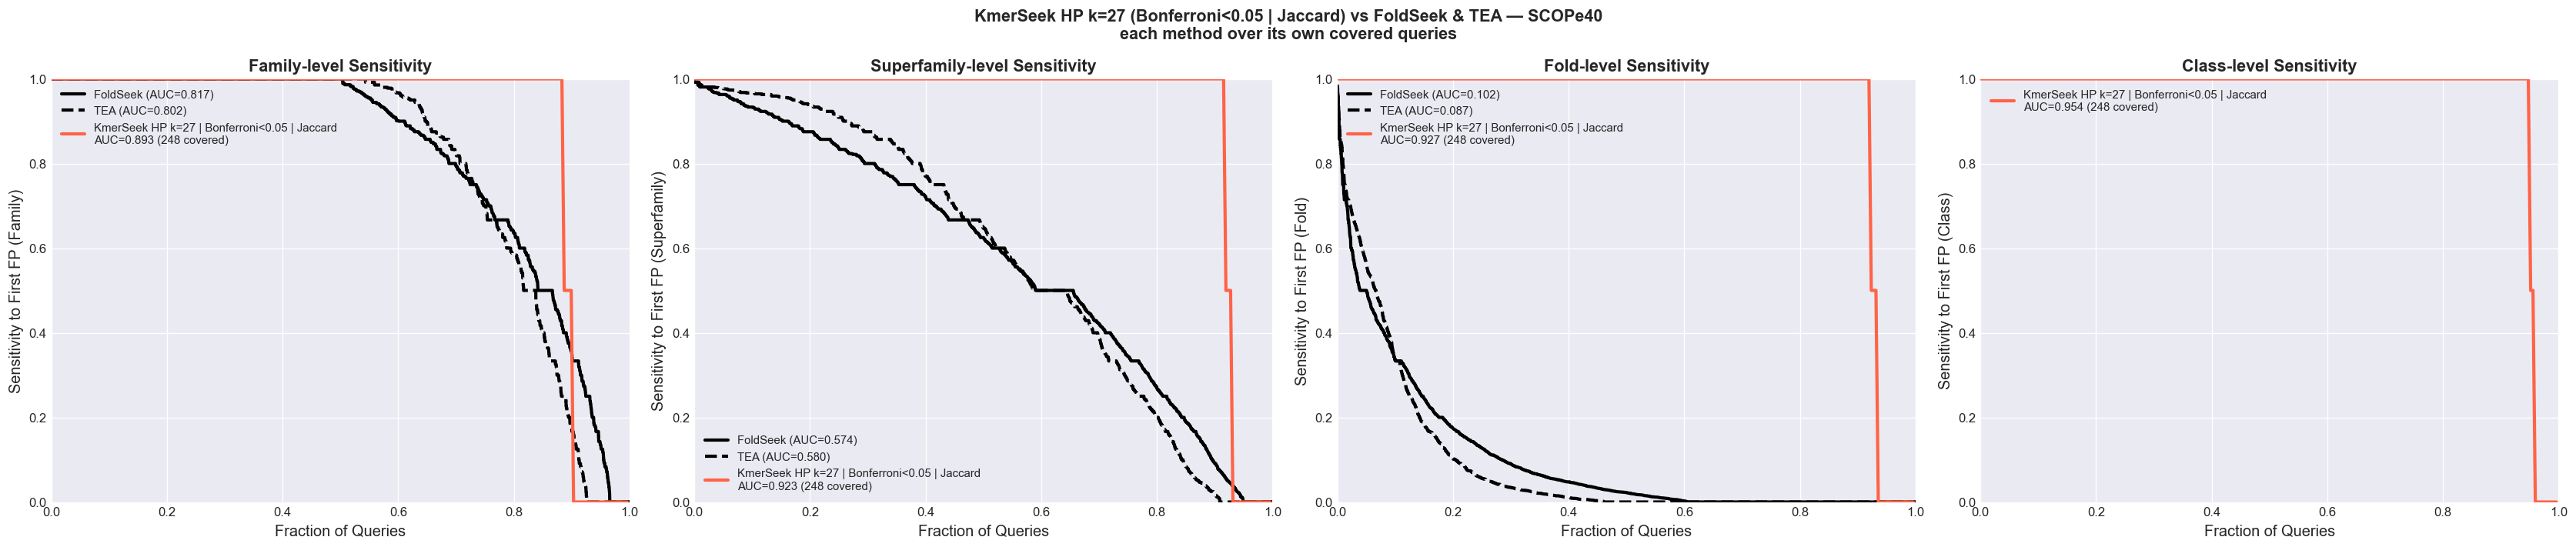

NAME,SCOP,CLASS,FAM,SFAM,FOLD,FP,CLASSCNT,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,f64,i32,i32,i32,i32,i32
"""d1aa6a2""","""c.81.1.1""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d1agja_""","""b.47.1.1""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d1aoea_""","""c.71.1.1""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d1b63a2""","""d.122.1.2""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d1c20a_""","""a.4.3.1""",1.0,1.0,1.0,1.0,0,1,1,1,1
…,…,…,…,…,…,…,…,…,…,…
"""d7bzkb_""","""c.47.1.0""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d7dkzl_""","""f.31.1.0""",1.0,1.0,1.0,1.0,0,1,1,1,1
"""d7lx0l_""","""f.31.1.0""",1.0,1.0,1.0,1.0,0,1,1,1,1


In [6]:
plot_best_metric_sensitivity(foldseek, tea_all, ref_queries, EXCLUDE_GRAY_ZONE, FIG_PREFIX)

## 6. k=24 vs k=27 sensitivity comparison

Loading k=24...
Loading k=27...


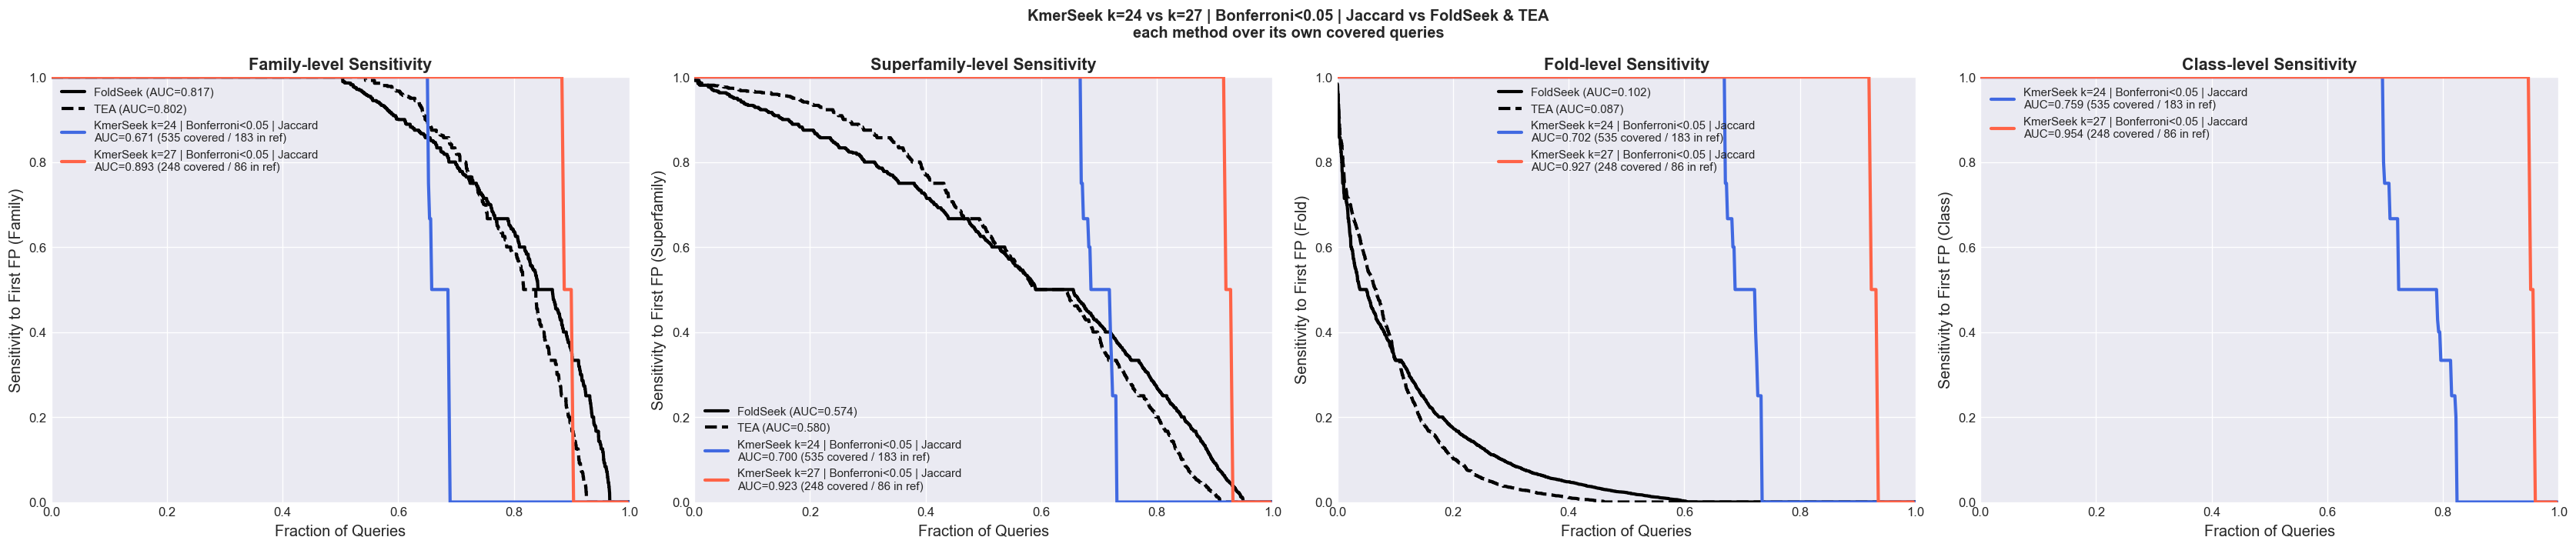

In [7]:
rocx_by_k = compute_k_comparison_rocx(foldseek, tea_all, ref_queries, EXCLUDE_GRAY_ZONE)
plot_k_comparison(rocx_by_k, foldseek, tea_all, ref_queries, FIG_PREFIX)

## 7. Shared queries sensitivity

k=24: 941 covered | 314 in ref | 308 shared w/ FoldSeek
k=27: 427 covered | 156 in ref | 150 shared w/ FoldSeek


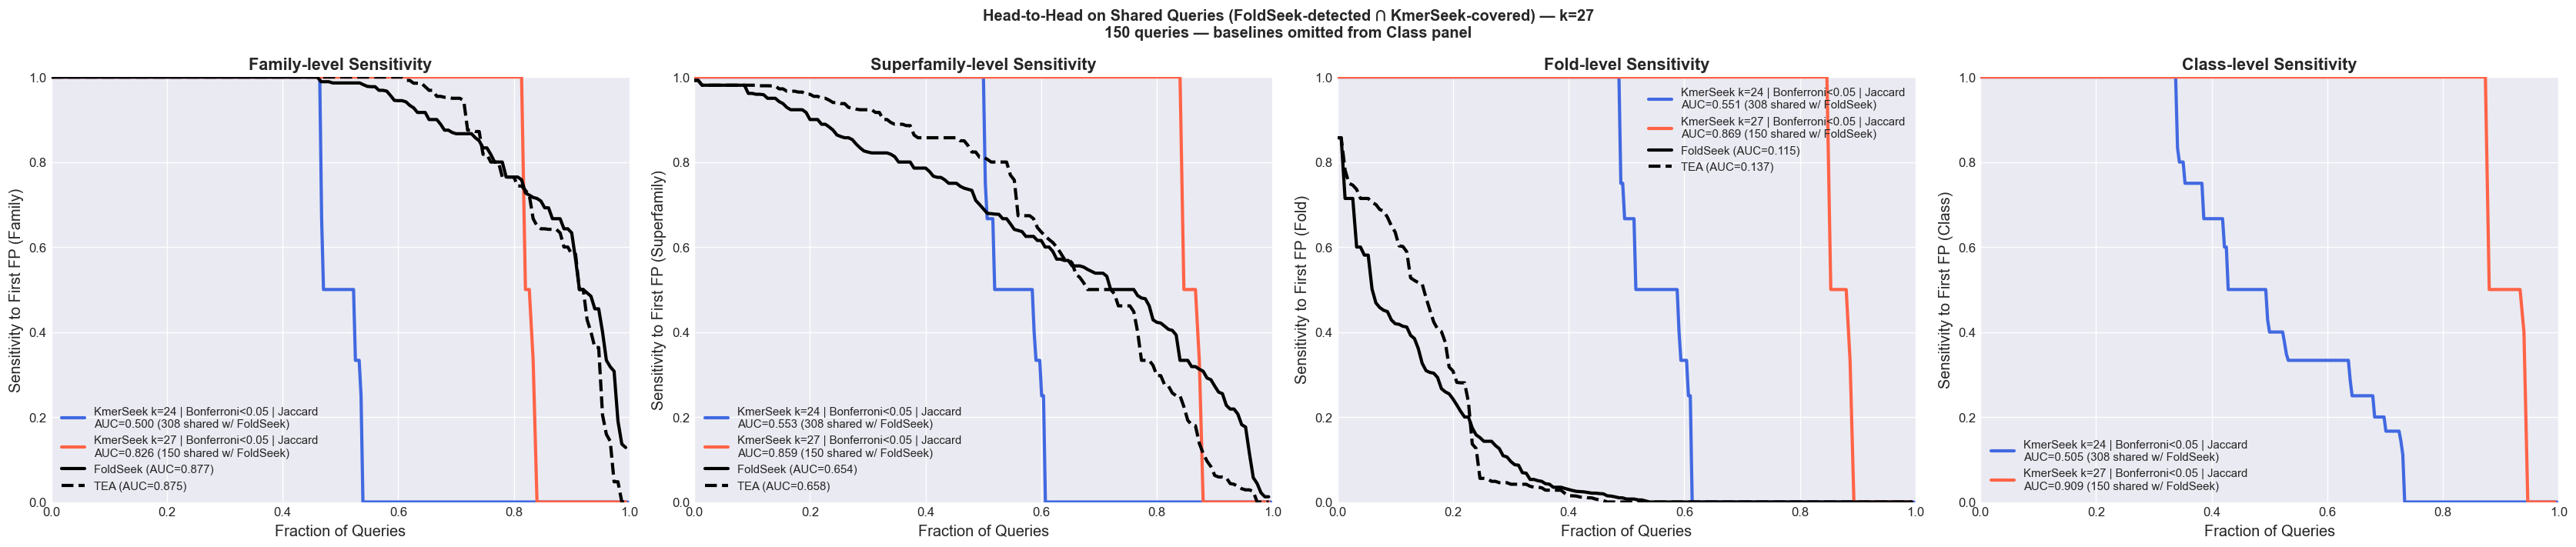

In [8]:
plot_shared_queries(foldseek, tea_all, ref_queries, EXCLUDE_GRAY_ZONE, FIG_PREFIX)

## 8. Metric category AUC

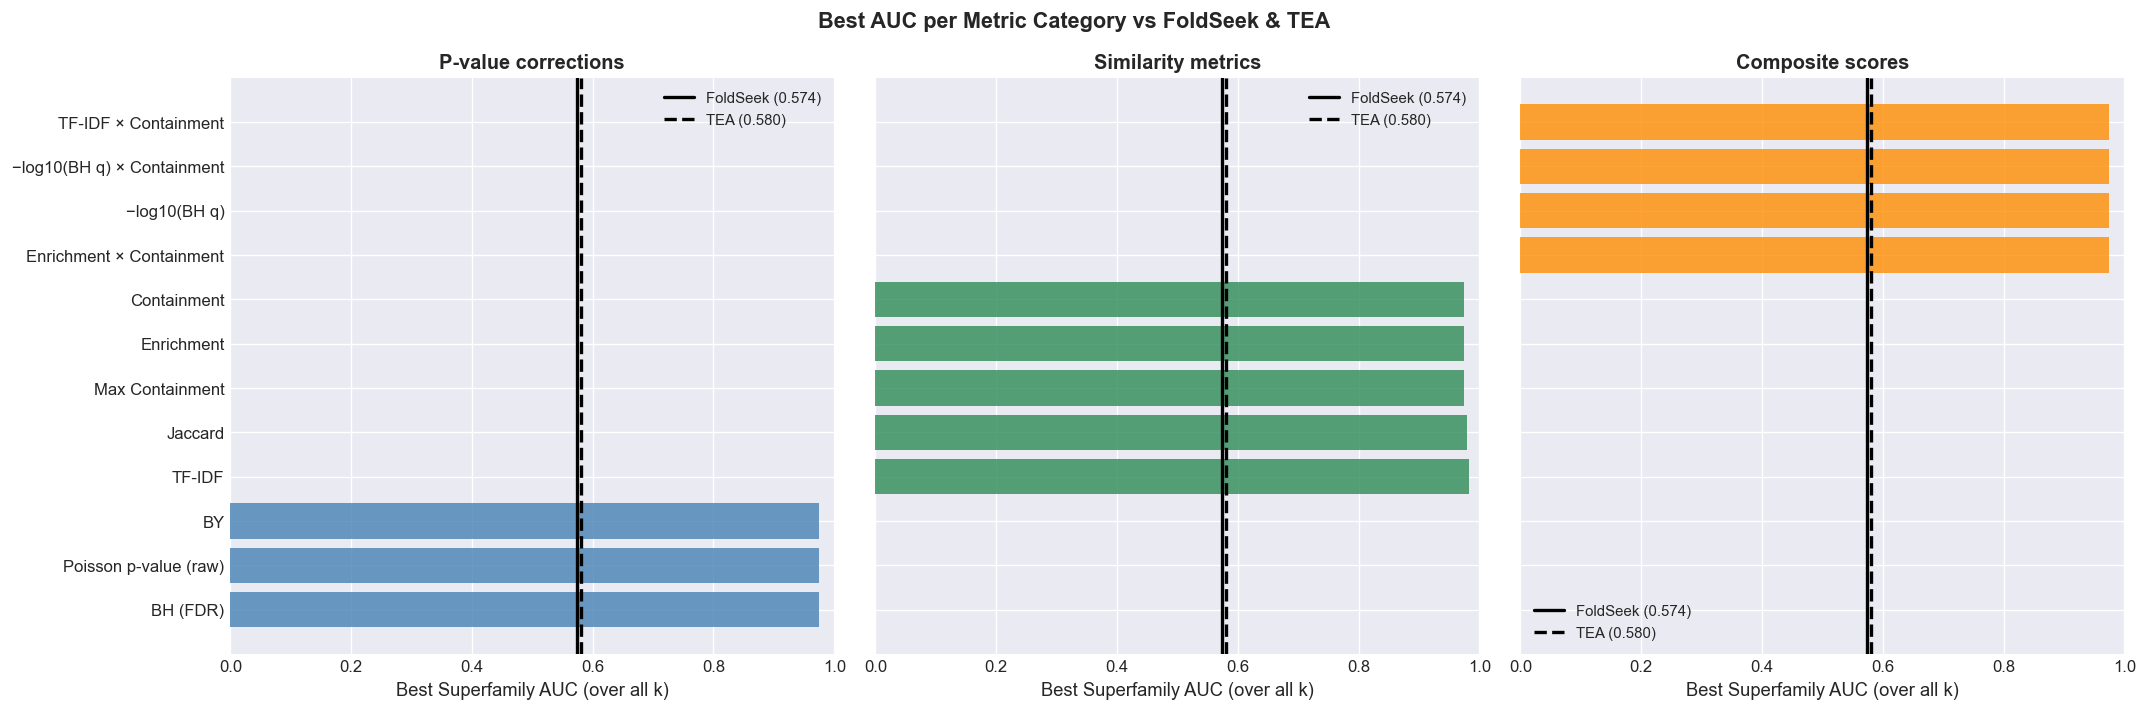

In [9]:
plot_metric_category_auc(auc_df, foldseek, tea_all, FIG_PREFIX)

## 9. AUC vs k-size line plots

/Users/olga/code/2024-kmerseek-analysis/notebooks/066_shared.py:498: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


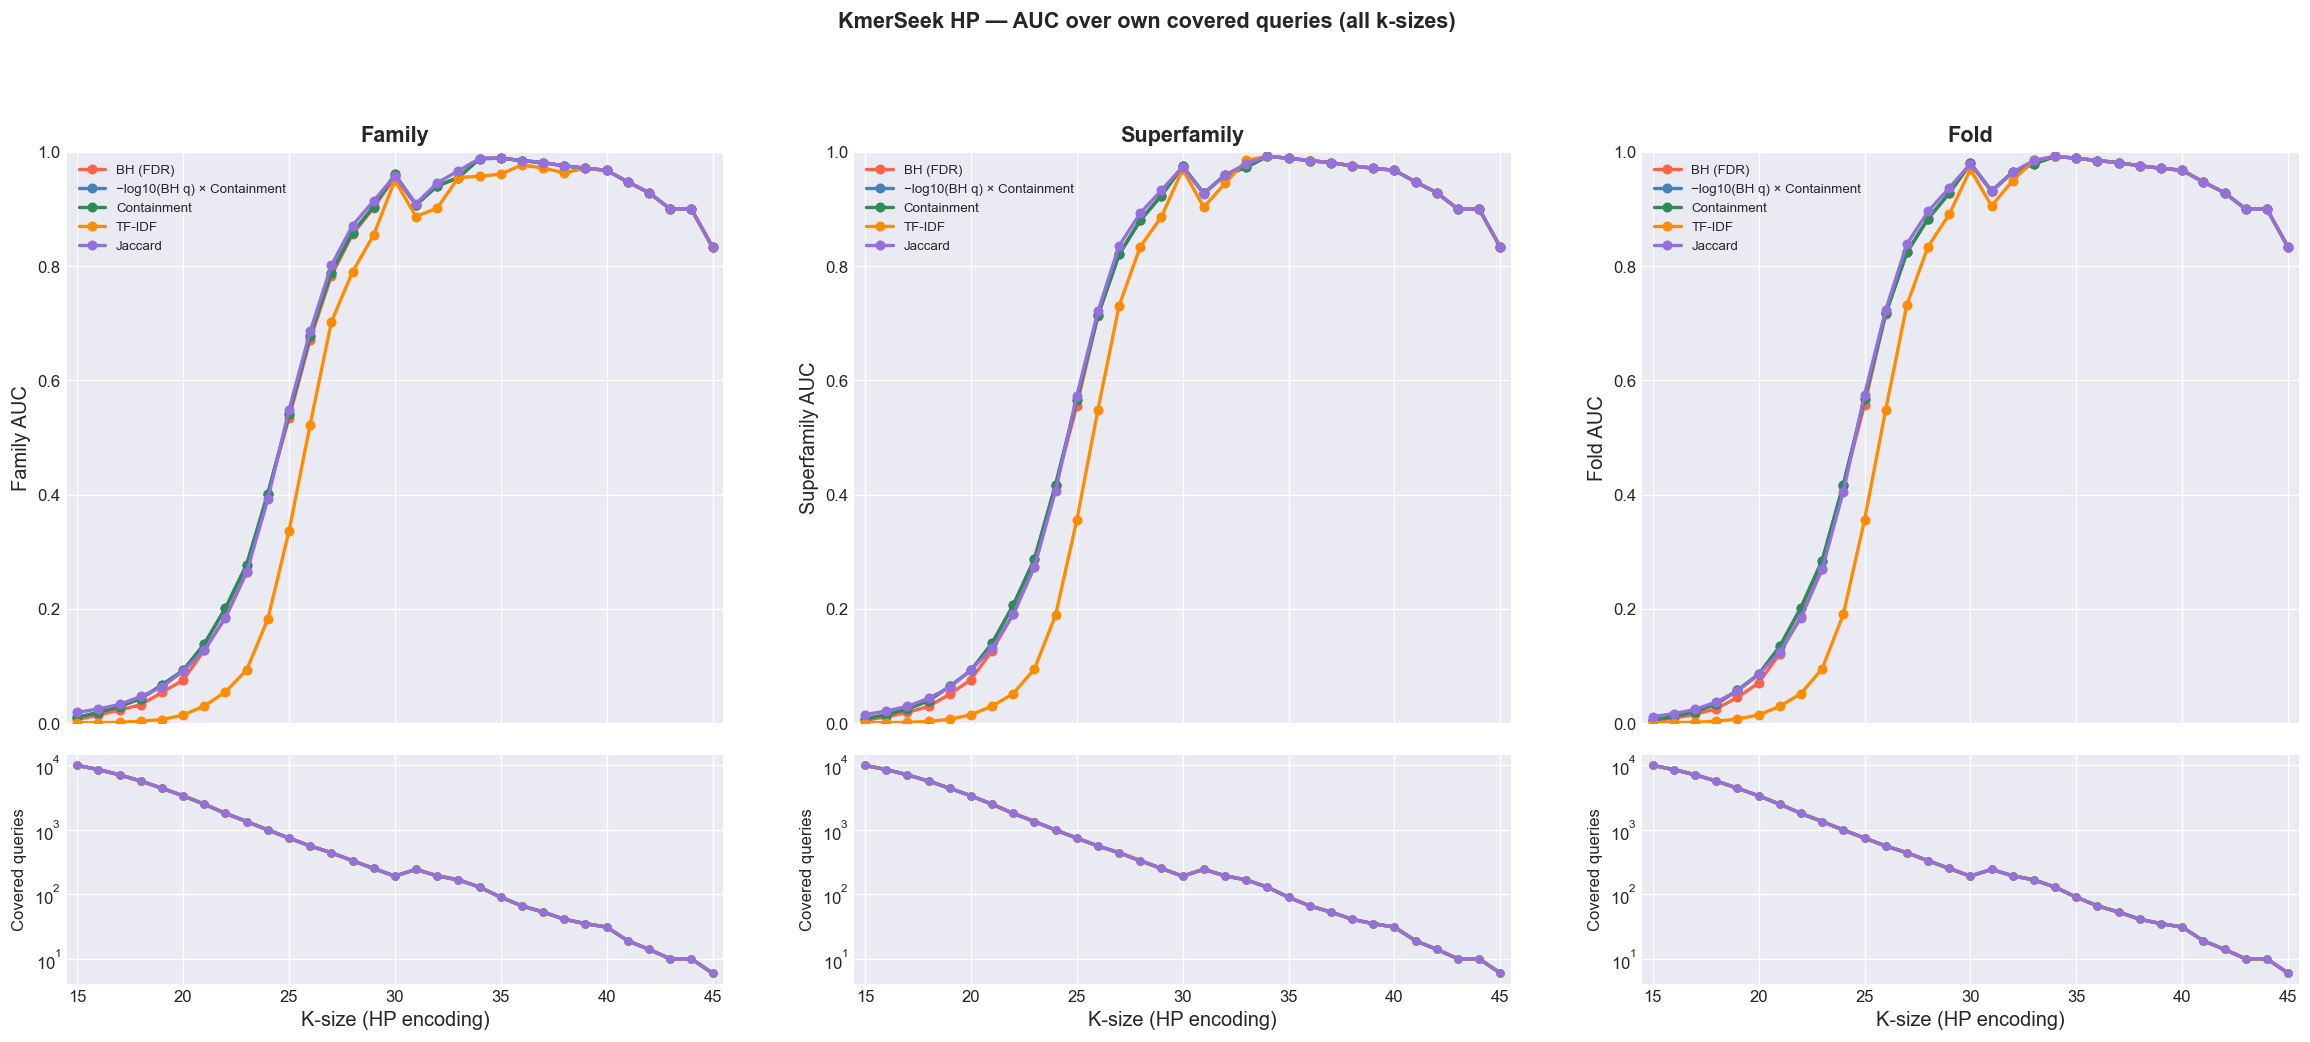

/Users/olga/code/2024-kmerseek-analysis/notebooks/066_shared.py:529: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


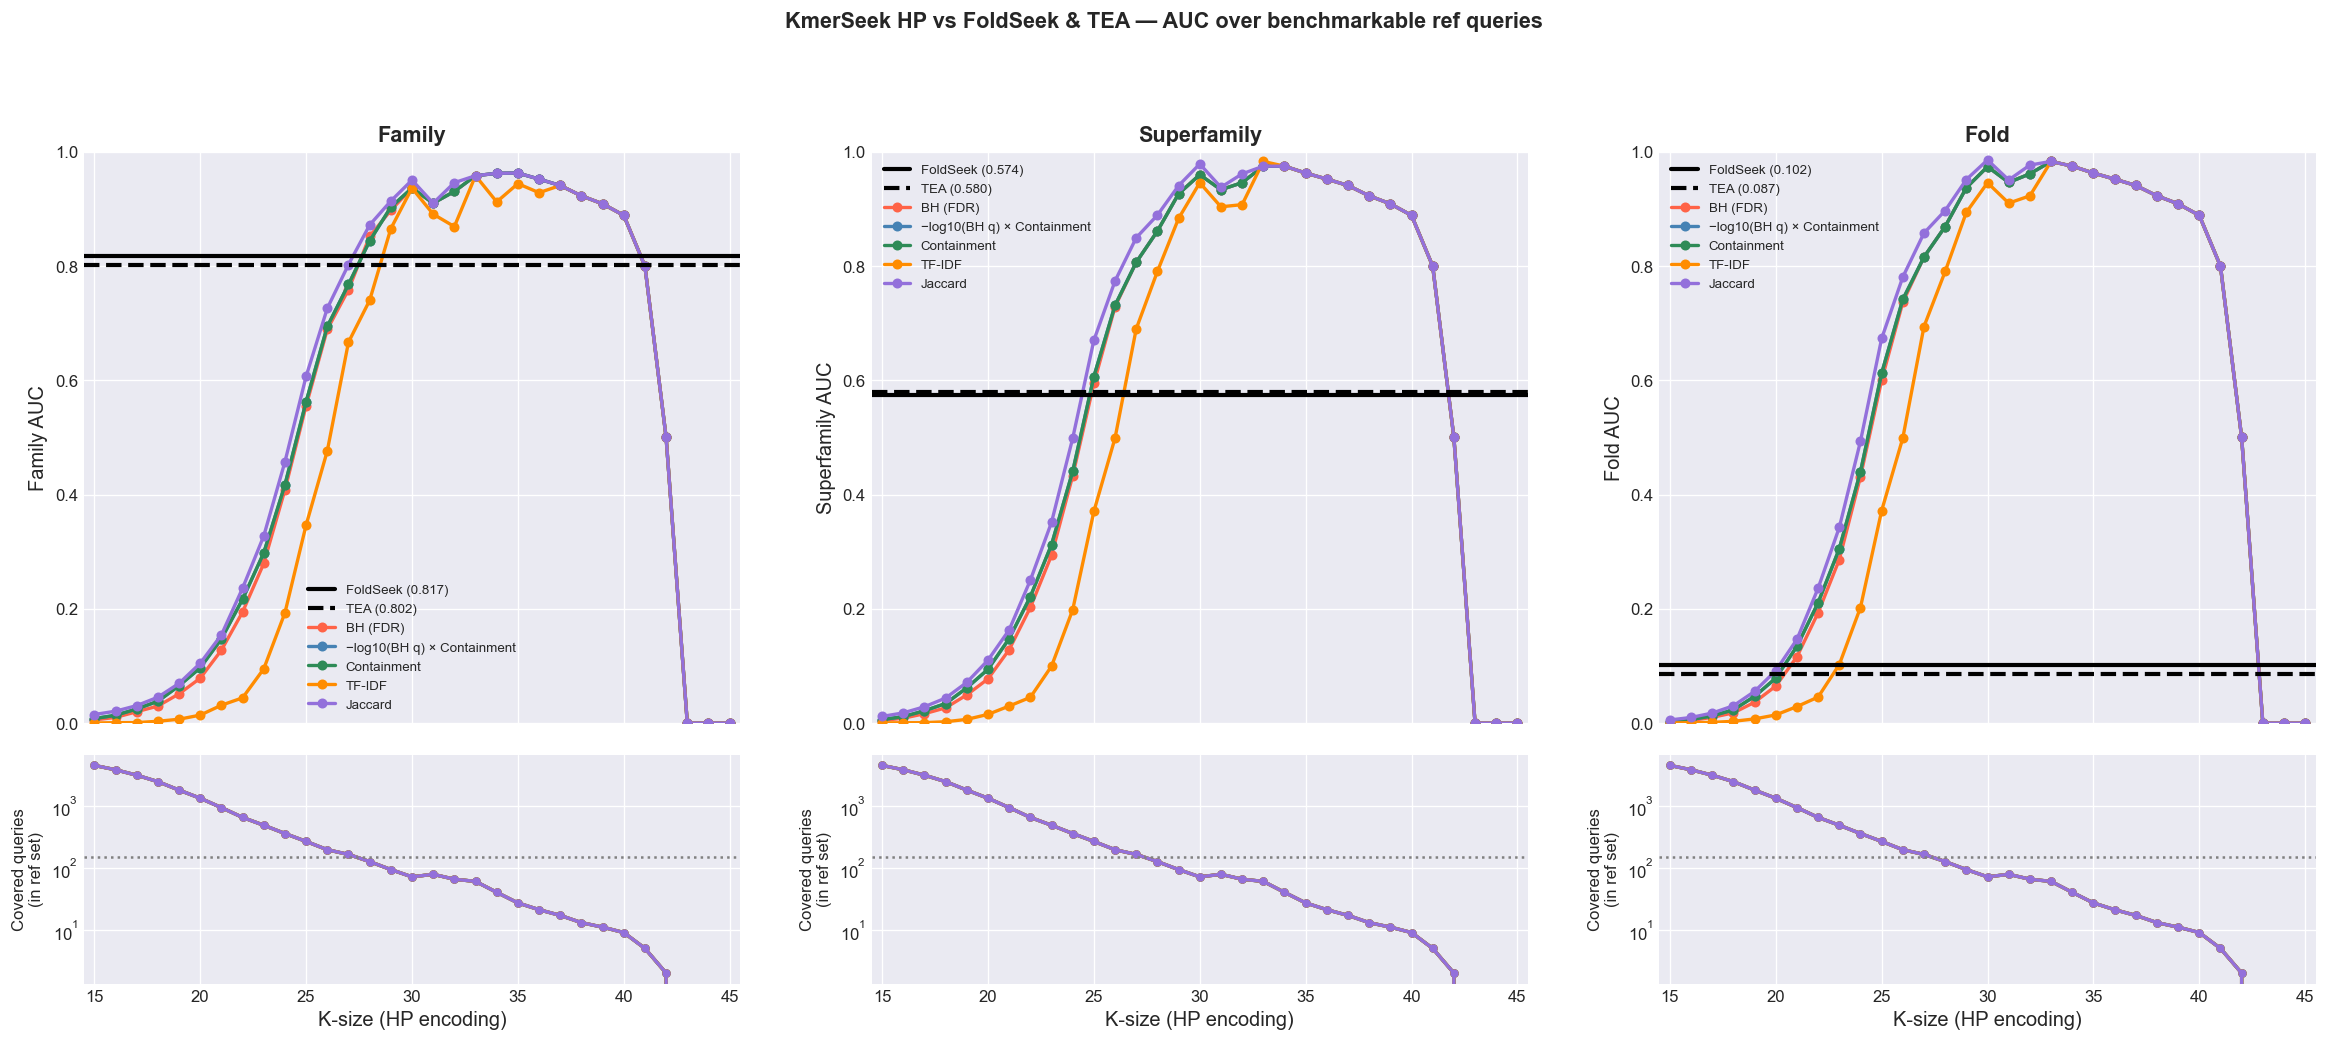

In [10]:
plot_auc_vs_ksize(auc_df, foldseek, tea_all, FIG_PREFIX)

## 10. Precision-recall curves

Loading k=24 for PR curves...
Loading k=27 for PR curves...


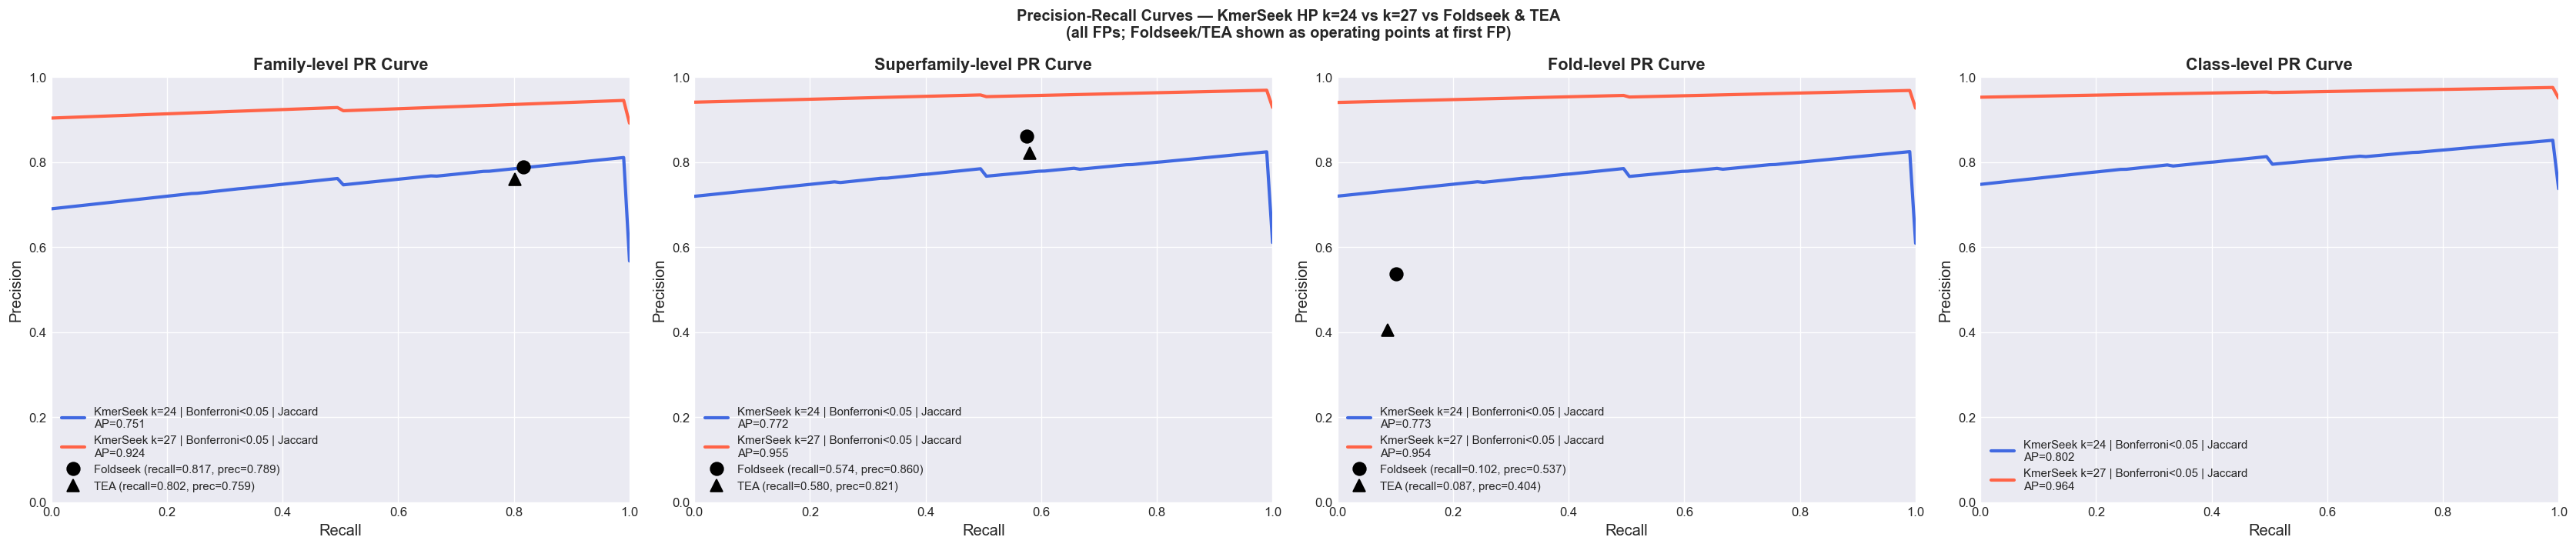

In [11]:
plot_precision_recall_curves(foldseek, tea_all, EXCLUDE_GRAY_ZONE, FIG_PREFIX)

## 11. Bonferroni sweep

k=15: n=1971, fam=0.226, sfam=0.238, fold=0.232
k=16: n=1813, fam=0.232, sfam=0.244, fold=0.238
k=17: n=1695, fam=0.228, sfam=0.237, fold=0.232
k=18: n=1602, fam=0.240, sfam=0.249, fold=0.245
k=19: n=1445, fam=0.251, sfam=0.263, fold=0.260
k=20: n=1274, fam=0.288, sfam=0.302, fold=0.301
k=21: n=1057, fam=0.342, sfam=0.362, fold=0.363
k=22: n=871, fam=0.418, sfam=0.447, fold=0.446
k=23: n=676, fam=0.532, sfam=0.560, fold=0.560
k=24: n=535, fam=0.671, sfam=0.700, fold=0.702
k=25: n=438, fam=0.781, sfam=0.806, fold=0.809
k=26: n=329, fam=0.841, sfam=0.875, fold=0.879
k=27: n=248, fam=0.893, sfam=0.923, fold=0.927
k=28: n=193, fam=0.940, sfam=0.962, fold=0.967
k=29: n=164, fam=0.966, sfam=0.985, fold=0.991
k=30: n=132, fam=0.989, sfam=0.992, fold=0.992
k=31: n=96, fam=0.984, sfam=0.990, fold=0.990
k=32: n=74, fam=0.986, sfam=0.986, fold=0.986
k=33: n=56, fam=0.982, sfam=0.982, fold=0.982
k=34: n=47, fam=0.979, sfam=0.979, fold=0.979
k=35: n=37, fam=0.973, sfam=0.973, fold=0.973
k=36: n=31,

/Users/olga/code/2024-kmerseek-analysis/notebooks/066_shared.py:682: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


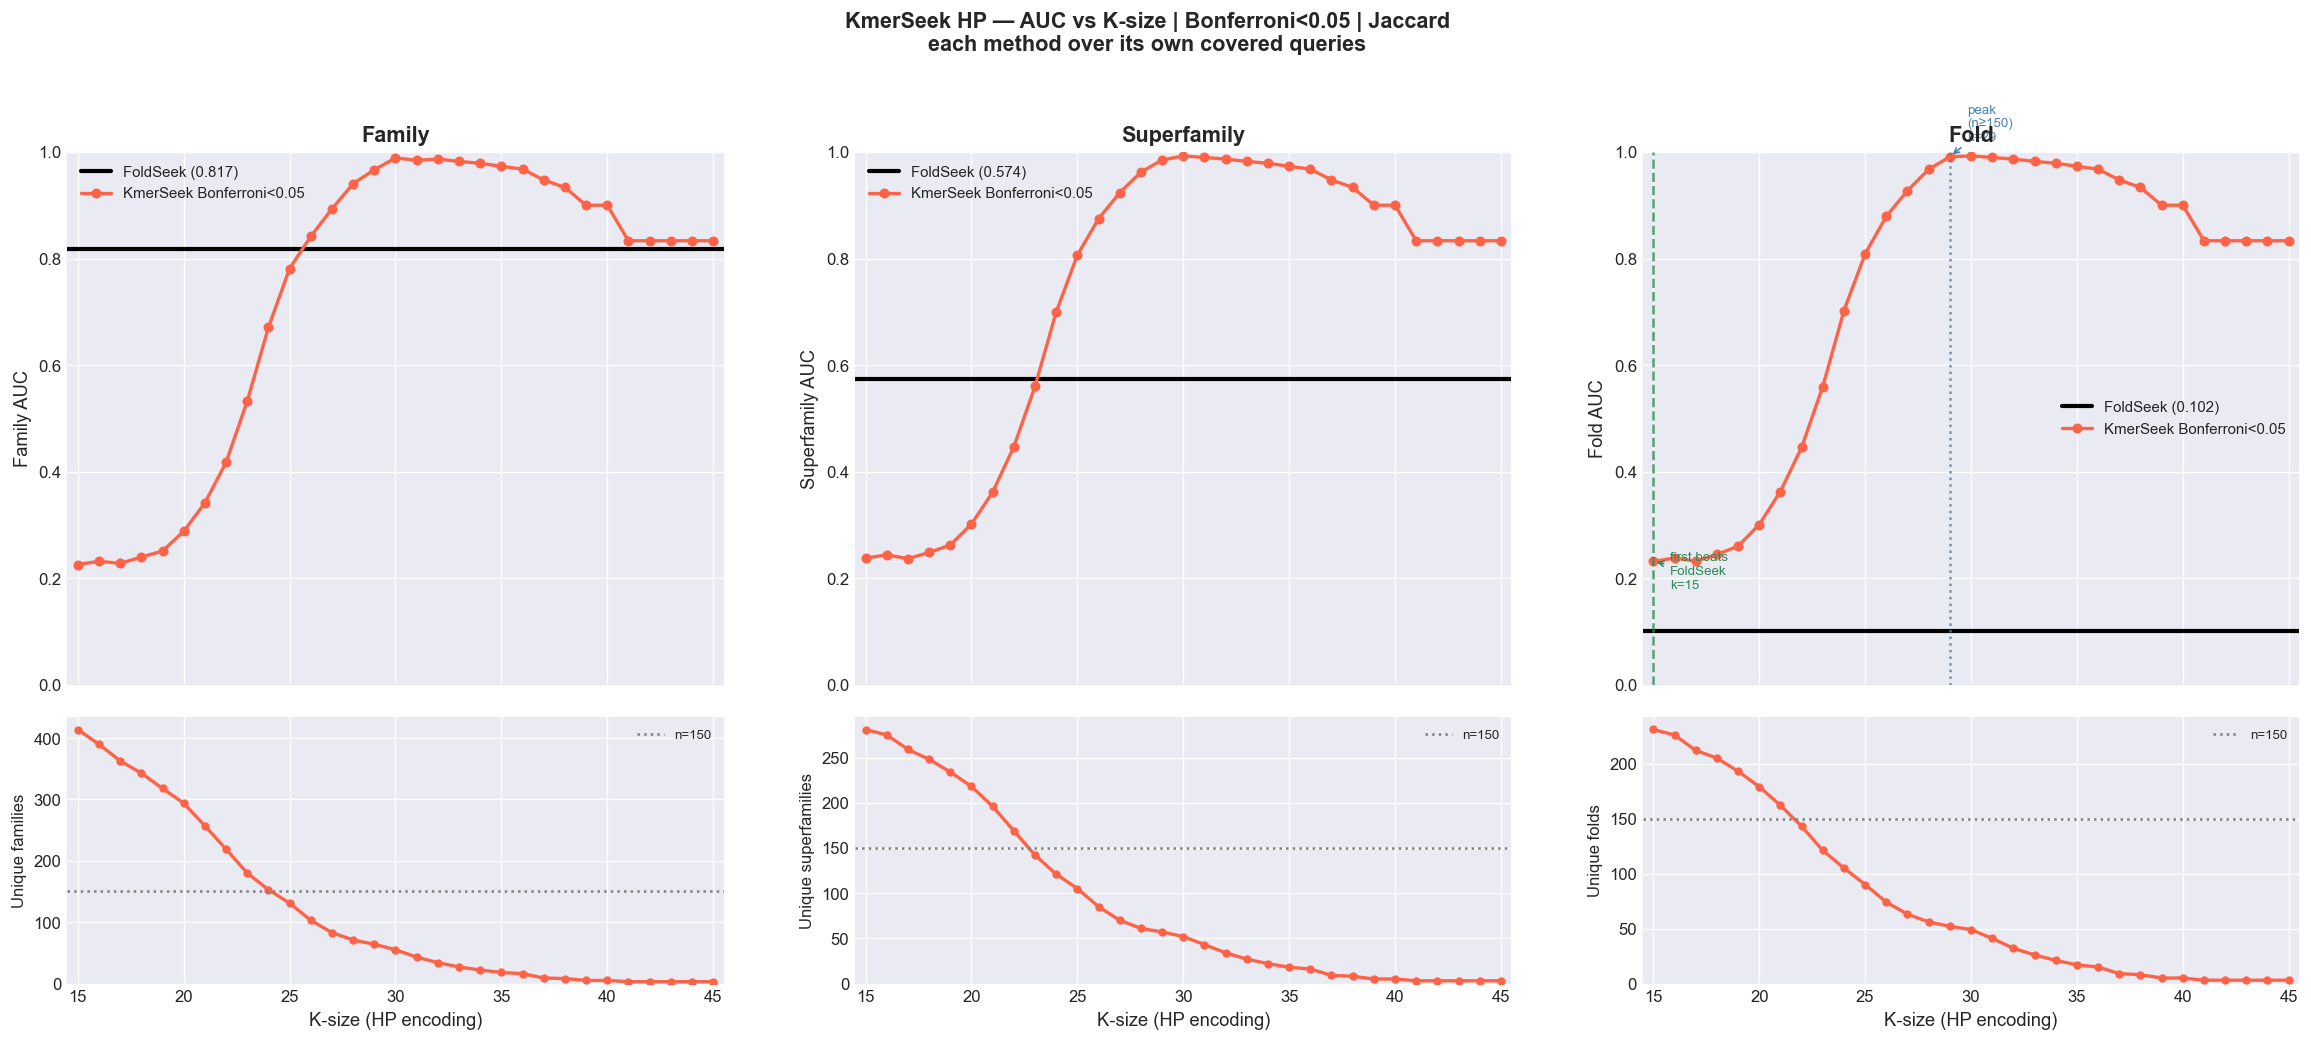

In [12]:
bonf_df = run_bonferroni_sweep(foldseek, tea_all, EXCLUDE_GRAY_ZONE, FIG_PREFIX)

## 12. Unique-hit combo analysis (Bonferroni + Jaccard)

In [ ]:
run_bonf_combo_analysis(bonf_df, foldseek, tea_all, ref_queries, EXCLUDE_GRAY_ZONE, FIG_PREFIX)

In [24]:
print_auc_comparison_table(ref_queries, foldseek, tea_all, EXCLUDE_GRAY_ZONE)

=== AUC COMPARISON TABLE (covered-query AUC) ===

Method                                                         FAM AUC  SFAM AUC  FOLD AUC  n_queries
---------------------------------------------------------------------------------------------------------
FoldSeek                                                        0.8169    0.5743    0.1017  5,713
TEA                                                             0.8020    0.5804    0.0868  5,737

  computing KmerSeek (n_queries ≥ 150): k=27 pval<0.001 Jaccard ...
KmerSeek (n_queries ≥ 150): k=27 pval<0.001 Jaccard             0.8323    0.8643    0.8739  156  (1.4%)
  computing KmerSeek (most queries, beats FoldSeek): k=24 pval<1e-05 Jaccard ...
KmerSeek (most queries, beats FoldSeek): k=24 pval<1e-05 Jaccard    0.5613    0.6113    0.6091  268  (2.4%)
